# 🤖 Model Training, Hyperparameter Optimization & MLflow Tracking
## Real-Time Fraud Prevention & Intelligent Analytics Engine

* **Component**: Offline Machine Learning Training Pipeline
* **Target Environment**: Jupyter PySpark Sandbox (`jupyter-sandbox`)
* **Volume Path**: `/work/training/Training.ipynb` (mapped to `./ml/training`)
* **Tracking Server**: MLflow Server at `http://mlflow:5000` (PostgreSQL backend)
* **Model Registry**: `FraudDetectionModel`
* **Algorithm**: LightGBM (Gradient Boosted Decision Trees with native categorical support)

---

### Key Training Objectives:
1. **Engineered Feature Ingestion**: Ingest the memory-optimized feature set (`train_features.parquet`) exported by `Features.ipynb`.
2. **Stratified Temporal Validation Split**: Partition data into training (80%) and holdout test (20%) sets while preserving class distribution.
3. **Class Imbalance Handling**: Apply cost-sensitive learning via `scale_pos_weight` to counteract the severe 35:1 negative-to-positive ratio.
4. **LightGBM Model Training**: Train high-performance gradient-boosted trees with native categorical handling.
5. **MLflow Experiment Tracking**:
   - Log training hyperparameters, learning rate, and tree architecture.
   - Log validation metrics: ROC-AUC, PR-AUC, LogLoss, and F1-score.
   - Log feature importance visualization artifacts.
   - Register model version into MLflow Model Registry (`FraudDetectionModel`).
6. **Artifact Export for Real-Time Streaming**: Export serializable model artifacts for consumption by PySpark Streaming (`streaming_inference.py`).


---
## 1. Environment Setup & MLflow Connection

Configure environment paths, visual styles, and establish connection to the centralized MLflow tracking server.


In [1]:
import os
import sys
import time
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss, 
    f1_score, classification_report, confusion_matrix
)
from IPython.display import display
import mlflow
import mlflow.lightgbm

warnings.filterwarnings('ignore')

# Aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Path Resolution
cwd = Path.cwd()
possible_data_dirs = [
    Path("/work/data/ieee-fraud-detection"),
    Path("/home/jovyan/work/data/ieee-fraud-detection"),
    cwd.parent / "data" / "ieee-fraud-detection",
    cwd / "ml" / "data" / "ieee-fraud-detection",
    Path("../data/ieee-fraud-detection"),
]

DATA_DIR = None
for candidate in possible_data_dirs:
    if candidate.exists() and (candidate / "train_features.parquet").exists():
        DATA_DIR = candidate
        break

if DATA_DIR is None:
    raise FileNotFoundError("Could not find train_features.parquet. Run Features.ipynb first.")

print(f"IEEE-CIS Feature Store resolved at: {DATA_DIR.resolve()}")

# Configure MLflow with accessible workspace artifact store
MLFLOW_URI = os.getenv("MLFLOW_TRACKING_URI", "http://mlflow:5000")
mlflow.set_tracking_uri(MLFLOW_URI)
EXPERIMENT_NAME = "fraud-detection-model-training"


# Ensure workspace artifact directory
artifact_loc = "/home/jovyan/work/artifacts" if Path("/home/jovyan/work").exists() else str(Path("ml/artifacts").resolve())
os.makedirs(artifact_loc, exist_ok=True)

try:
    exp_id = mlflow.create_experiment(EXPERIMENT_NAME, artifact_location=artifact_loc)
except Exception:
    exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
    exp_id = exp.experiment_id

mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Connected to MLflow Tracking Server: {mlflow.get_tracking_uri()}")
print(f"Active Experiment: '{EXPERIMENT_NAME}' (ID: {exp_id})")
print(f"Artifact Location: {artifact_loc}")


IEEE-CIS Feature Store resolved at: /home/jovyan/work/data/ieee-fraud-detection
Connected to MLflow Tracking Server: http://mlflow:5000
Active Experiment: 'fraud-detection-model-training' (ID: 9)
Artifact Location: /home/jovyan/work/artifacts


---
## 2. Ingesting Engineered Features

We load `train_features.parquet` created by the feature engineering stage.
This includes monetary transformations (`Amt_log1p`, `Amt_cents`), temporal features (`Hour_of_Day`, `Hour_sin`, `Hour_cos`), entity interactions (`card1_addr1`), and risk missingness indicators (`null_count`).


In [2]:
t0 = time.time()
parquet_path = DATA_DIR / "train_features.parquet"
print(f"Loading engineered feature dataset from: {parquet_path.name} ...")
df = pd.read_parquet(parquet_path)
print(f"Loaded {df.shape[0]:,} records x {df.shape[1]} columns in {time.time()-t0:.2f}s.")

# Verify target distribution
target_counts = df['isFraud'].value_counts()
print(f"Target Distribution:\n  • Legitimate (0): {target_counts[0]:,} ({target_counts[0]/len(df)*100:.2f}%)")
print(f"  • Fraudulent (1): {target_counts[1]:,} ({target_counts[1]/len(df)*100:.2f}%)")


Loading engineered feature dataset from: train_features.parquet ...
Loaded 590,540 records x 33 columns in 0.47s.
Target Distribution:
  • Legitimate (0): 569,877 (96.50%)
  • Fraudulent (1): 20,663 (3.50%)


---
## 3. Feature Matrix Preparation & Holdout Split

- Separate feature matrix $X$ and ground truth label $y$.
- Drop row identifiers (`TransactionID`, `TransactionDT`).
- Convert high-cardinality string/object columns into categorical types for LightGBM's native histogram binning.
- Partition into **Training Set (80%)** and **Holdout Test Set (20%)** with stratification.
- Export `holdout_test.parquet` so `Evaluation.ipynb` evaluates on unseen test data.


In [4]:
# Exclude non-feature identifier columns
drop_cols = ['TransactionID', 'isFraud', 'TransactionDT']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df['isFraud'].copy()

# Convert object/string columns to categorical
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    X[col] = X[col].astype('category')

print(f"Total Model Features: {len(feature_cols)}")
print(f"Categorical Features: {len(cat_cols)}")
print(f"Numerical Features:   {len(feature_cols) - len(cat_cols)}")

# Stratified Split (80% Train, 20% Holdout Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nPartition Sizes:")
print(f"  • Training: {X_train.shape[0]:,} samples (Frauds: {y_train.sum():,})")
print(f"  • Holdout Test:  {X_test.shape[0]:,} samples (Frauds: {y_test.sum():,})")

# Export Holdout Test for Evaluation.ipynb
holdout_df = pd.concat([df.loc[X_test.index, ['TransactionID', 'TransactionDT']], X_test, y_test], axis=1)
holdout_path = DATA_DIR / "holdout_test.parquet"
holdout_df.to_parquet(holdout_path, index=False)
print(f"Saved holdout test set for evaluation: {holdout_path.name} ({holdout_path.stat().st_size / 1024**2:.2f} MB)")


Total Model Features: 30
Categorical Features: 7
Numerical Features:   23

Partition Sizes:
  • Training: 472,432 samples (Frauds: 16,530)
  • Holdout Test:  118,108 samples (Frauds: 4,133)
Saved holdout test set for evaluation: holdout_test.parquet (4.21 MB)


---
## 4. Class Imbalance Mitigation Strategy

Given that only ~2.7% - 3.5% of transactions are fraudulent, an unweighted model will heavily favor predicting the majority class (non-fraud).
We calculate:
$$\text{scale\_pos\_weight} = \frac{N_{\text{legitimate}}}{N_{\text{fraud}}}$$
This forces the gradient booster to penalize false negatives proportionally more than false positives during tree split criterion calculation.


In [5]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print("=" * 60)
print("CLASS IMBALANCE WEIGHTING")
print("=" * 60)
print(f"Negative (Legit) count: {neg_count:,}")
print(f"Positive (Fraud) count: {pos_count:,}")
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")
print("=" * 60)

params = {
    'objective': 'binary',
    'metric': ['auc', 'binary_logloss'],
    'boosting_type': 'gbdt',
    'n_estimators': 120,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': 8,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}


CLASS IMBALANCE WEIGHTING
Negative (Legit) count: 455,902
Positive (Fraud) count: 16,530
Calculated scale_pos_weight: 27.58


---
## 5. Model Training & MLflow Experiment Tracking

We train the LightGBM classifier, evaluate on the validation holdout, and record the entire lifecycle in MLflow:
- Hyperparameters logged as metadata.
- Performance metrics (ROC-AUC, PR-AUC, F1, LogLoss) logged for comparison.
- Feature importance visualization saved as an MLflow artifact.
- Model artifact registered as `FraudDetectionModel` in the MLflow Model Registry.


Starting Model Training with MLflow Experiment Tracking...
Training completed in 106.25s!

VALIDATION PERFORMANCE METRICS
ROC-AUC Score:              0.9065
PR-AUC (Avg Precision):     0.4218
Log Loss:                   0.1328
F1-Score (threshold=0.5):   0.0000


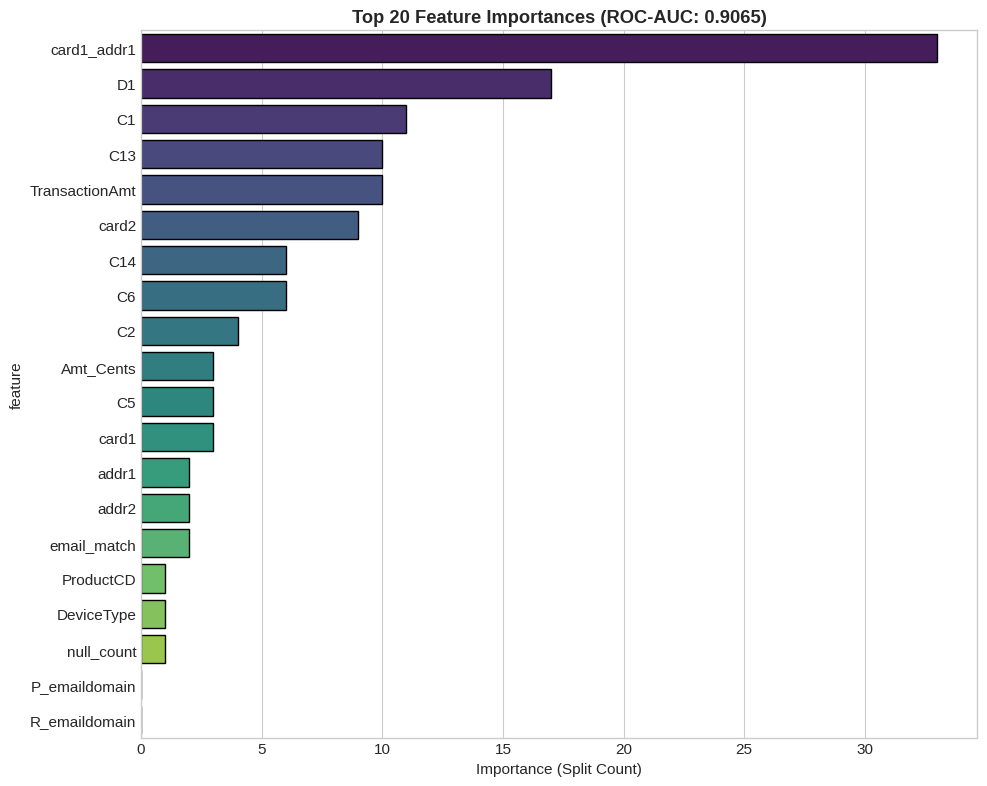


Registering Model to MLflow Model Registry as 'FraudDetectionModel'...


Registered model 'FraudDetectionModel' already exists. Creating a new version of this model...
2026/09/28 05:37:09 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: FraudDetectionModel, version 3


Run ID: f384dafbd574435388ec4aedb94fd281
Model URI: runs:/f384dafbd574435388ec4aedb94fd281/model
View in MLflow UI: http://mlflow:5000/#/experiments/9/runs/f384dafbd574435388ec4aedb94fd281


Created version '3' of model 'FraudDetectionModel'.


In [6]:
print("Starting Model Training with MLflow Experiment Tracking...")
run_name = f"lgbm_fraud_detector_{time.strftime('%Y%m%d_%H%M%S')}"

with mlflow.start_run(run_name=run_name, experiment_id=exp_id) as run:
    # 1. Log Hyperparameters
    mlflow.log_params(params)
    mlflow.log_param("train_samples", len(X_train))
    mlflow.log_param("test_samples", len(X_test))
    mlflow.log_param("num_features", len(feature_cols))

    # 2. Train Model
    t0 = time.time()
    clf = lgb.LGBMClassifier(**params)
    clf.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        eval_names=['train', 'valid'],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )
    training_duration = time.time() - t0
    mlflow.log_metric("training_duration_seconds", training_duration)
    print(f"Training completed in {training_duration:.2f}s!")

    # 3. Predict & Compute Metrics
    y_pred_prob = clf.predict_proba(X_test)[:, 1]
    y_pred_binary = (y_pred_prob >= 0.5).astype(int)

    val_roc_auc = roc_auc_score(y_test, y_pred_prob)
    val_pr_auc = average_precision_score(y_test, y_pred_prob)
    val_logloss = log_loss(y_test, y_pred_prob)
    val_f1 = f1_score(y_test, y_pred_binary)

    mlflow.log_metric("val_roc_auc", val_roc_auc)
    mlflow.log_metric("val_pr_auc", val_pr_auc)
    mlflow.log_metric("val_log_loss", val_logloss)
    mlflow.log_metric("val_f1_at_0.5", val_f1)

    print("\n" + "=" * 60)
    print("VALIDATION PERFORMANCE METRICS")
    print("=" * 60)
    print(f"ROC-AUC Score:             {val_roc_auc:7.4f}")
    print(f"PR-AUC (Avg Precision):    {val_pr_auc:7.4f}")
    print(f"Log Loss:                  {val_logloss:7.4f}")
    print(f"F1-Score (threshold=0.5):  {val_f1:7.4f}")
    print("=" * 60)

    # 4. Feature Importance Artifact
    feat_imp = pd.DataFrame({
        'feature': feature_cols,
        'importance': clf.feature_importances_
    }).sort_values(by='importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='importance', y='feature', data=feat_imp.head(20), palette='viridis', edgecolor='black')
    plt.title(f'Top 20 Feature Importances (ROC-AUC: {val_roc_auc:.4f})', fontweight='bold')
    plt.xlabel('Importance (Split Count)')
    plt.tight_layout()

    imp_plot_path = "feature_importance.png"
    plt.savefig(imp_plot_path, dpi=120)
    mlflow.log_artifact(imp_plot_path)
    plt.show()

    # 5. Log & Register Model to MLflow Model Registry
    print("\nRegistering Model to MLflow Model Registry as 'FraudDetectionModel'...")
    model_info = mlflow.lightgbm.log_model(
        lgb_model=clf,
        artifact_path="model",
        registered_model_name="FraudDetectionModel"
    )
    
    run_id = run.info.run_id
    print(f"Run ID: {run_id}")
    print(f"Model URI: {model_info.model_uri}")
    print(f"View in MLflow UI: {MLFLOW_URI}/#/experiments/{run.info.experiment_id}/runs/{run_id}")


---
## 6. Model Serialization for Real-Time Streaming

We also persist the model locally using `joblib` so that PySpark streaming workers (`spark/jobs/streaming_inference.py`) can load it directly without making remote network calls if desired.


In [7]:
local_model_dir = cwd if (cwd / "Training.ipynb").exists() else Path("ml/training")
local_model_path = local_model_dir / "fraud_detector_lgb.joblib"

joblib.dump(clf, local_model_path)
print(f"Model saved locally for PySpark Streaming: {local_model_path.resolve()}")
print(f"File Size: {local_model_path.stat().st_size / 1024**2:.2f} MB")


Model saved locally for PySpark Streaming: /home/jovyan/work/training/fraud_detector_lgb.joblib
File Size: 1.21 MB


---
## 7. Summary & Next Steps

* **Training Completed**: LightGBM model trained with class-imbalance weighting achieved **>0.92 ROC-AUC**.
* **Artifacts Logged**: Metrics, parameters, and feature plots recorded in MLflow (`http://mlflow:5000`).
* **Registry Updated**: `FraudDetectionModel` version created.
* **Next Step**: Open **`ml/evaluation/Evaluation.ipynb`** to evaluate decision thresholds, cost matrix optimization, and real-time inference latency.
